# 0 - Import libraries

In [1]:
import tamubo.exactbo as ebo
import cupynumeric as cp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from partition_cupynumeric import split_boxes
from bound_cupynumeric import rbf_k_bounds, mu_bounds, sigma_bounds, ei_bounds
from ei_cupynumeric import expected_improvement
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# 1 - Define initial steps as usual

In [2]:
# Define model
kernel = ConstantKernel(1.0, (1e-2, 1e3)) * RBF(length_scale=0.2, length_scale_bounds=(1e-2, 10.0)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-10, 1e1))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)

# Define bounds
bounds = np.array([[0,1],[0,1]])

# Define initial box
init_box = ebo.Box(bounds,True)

# Function to minimize
# f(x,y)= \alpha(x^2 + y^2) - \sum_{i=1}^3 A_i \exp \left( -\frac{(x - Cx_i)^2 + (y - Cy_i)^2}{B_i} \right) + D
def f(X):
    if len(X.shape) == 1:
        X = X.reshape(1,-1)
        
    x, y = X[:,0], X[:,1]

    # Parameters
    alpha = 0.1
    A  = np.array([4, 3, 2])
    B  = np.array([0.08, 0.05, 0.02])    # betas
    C  = np.array([[0.9, 0.3 ],      # centers (x1,y1)
                [0.1 , 0.8],
                [0.6 , 0.7 ]])
    D = 2
    
    # Compute function value
    val = alpha*(x**2 + y**2)
    for Ai, Bi, (xi, yi) in zip(A, B, C):
        r2 = (x - xi)**2 + (y - yi)**2
        val -= Ai * np.exp(-r2 / Bi)
    val += D
    return val

# Create initial points and evaluate
X0 = np.array([[0.25,0.25],[0.25,0.75],[0.75,0.25],[0.75,0.75]])
X0_cp = cp.array(X0.tolist())

N = X0.shape[0]

y0 = f(X0)

# Train model
gp.fit(X0,y0.ravel())

# Get information from gp
gp_kernel_params = gp.kernel_.get_params()
sigma_f_2 = gp_kernel_params['k1__k1__constant_value']
length_scale = gp_kernel_params['k1__k2__length_scale']
sigma_n_2 = gp_kernel_params['k2__noise_level']
alpha = cp.array(gp.alpha_)
y_train_std = gp._y_train_std
y_train_mean = gp._y_train_mean
L = cp.array(gp.L_)
y_min = cp.min(gp.y_train_)
y_min_unscaled = y_train_std * y_min + y_train_mean

# Define boxes object
boxes = ebo.Boxes([init_box])

# Number of boxes
n = len(boxes)
d = init_box.dim
w = cp.array(init_box.width)
ei_max = 0

# Boxes bounds to cupynumeric
boxes_bounds = boxes.bounds.reshape(n*d,2)
boxes_bounds_L = cp.array(boxes_bounds[:,0].reshape(n,d))
boxes_bounds_R = cp.array(boxes_bounds[:,1].reshape(n,d))

# 2 - Partition and Bound Loop

In [13]:
ns = []
#times = []
Ls = []
Rs = []
K_los = []
K_his = []
mu_los = []
mu_his = []
sig_los = []
sig_his = []
ei_los = []
ei_his = []
for _ in range(5):
    # Number of boxes change at each partition
    n = boxes_bounds_L.shape[0]

    # Find kernel bounds (timing it)
    #start_time = time()
    K_lo = cp.zeros((n,N))
    K_hi = cp.zeros((n,N))
    for i in range(N):
        xi = X0_cp[i]
        K_lo[:,i], K_hi[:,i] = rbf_k_bounds(boxes_bounds_L.ravel(),boxes_bounds_R.ravel(),xi,n,d,sigma_f_2,length_scale)
    #end_time = time()

    mu_lo, mu_hi = mu_bounds(alpha,K_lo,K_hi,n,N,y_train_mean,y_train_std)
    sig_lo, sig_hi = sigma_bounds(K_lo,K_hi,L,n,N,sigma_f_2,y_train_std)
    ei_lo, ei_hi = ei_bounds(mu_lo,mu_hi,sig_lo,sig_hi,y_min,y_train_mean,y_train_std)

    # Compute actual EI in the center of the hyperbox with highest upper EI bound
    idx_max_ei_hi = cp.argmax(ei_hi)
    max_ei_hi_box_L = boxes_bounds_L[idx_max_ei_hi,:]  # (d,)
    max_ei_hi_box_U = boxes_bounds_R[idx_max_ei_hi,:]  # (d,)
    max_ei_hi_box_center = (max_ei_hi_box_L + max_ei_hi_box_U) / 2.0  # (d,)
    mu_pred, sigma_pred = gp.predict(np.array(max_ei_hi_box_center).reshape(1,-1), return_std=True)
    ei_max = max(ei_max,expected_improvement(mu_pred[0], sigma_pred[0], y_min_unscaled))

    # Active boxes are the ones where ei_hi is higher than ei_max
    active_boxes_mask = ei_hi > ei_max  # (n,)

    # Update maximum with of active boxes
    w_max = cp.max(boxes_bounds_L[active_boxes_mask] - boxes_bounds_R[active_boxes_mask], axis=0)

    # Save results
    ns.append(n)
    #times.append((end_time-start_time)/1e6)
    Ls.append(boxes_bounds_L)
    Rs.append(boxes_bounds_R)
    K_los.append(K_lo)
    K_his.append(K_hi)
    mu_los.append(mu_lo)
    mu_his.append(mu_hi)
    sig_los.append(sig_lo)
    sig_his.append(sig_hi)
    ei_los.append(ei_lo)
    ei_his.append(ei_hi)

    # Split boxes
    boxes_bounds_L, boxes_bounds_R = split_boxes(boxes_bounds_L, boxes_bounds_R, active_boxes_mask, w, n, d)

# 3 - Plotting

In [2]:
def plot_rectangles(bounds_L, bounds_U, pad=0.01):
    bounds_L = np.asarray(bounds_L)
    bounds_U = np.asarray(bounds_U)
    assert bounds_L.shape == bounds_U.shape and bounds_L.shape[1] == 2

    widths = bounds_U[:, 0] - bounds_L[:, 0]
    heights = bounds_U[:, 1] - bounds_L[:, 1]

    inset_ll = bounds_L + pad
    inset_w = np.maximum(widths - 2 * pad, 0)
    inset_h = np.maximum(heights - 2 * pad, 0)

    fig, ax = plt.subplots()
    for (x, y), w, h in zip(inset_ll, inset_w, inset_h):
        ax.add_patch(Rectangle((x, y), w, h,
                               fill=False,
                               linewidth=2.0,
                               edgecolor='C0'))
    ax.set_aspect('equal', adjustable='box')
    ax.autoscale_view()
    plt.show()


Starting splitting test with intial box with bounds: [[0. 0.]] [[1. 1.]]
Initial box width: [1. 1.]
Dimension: 2


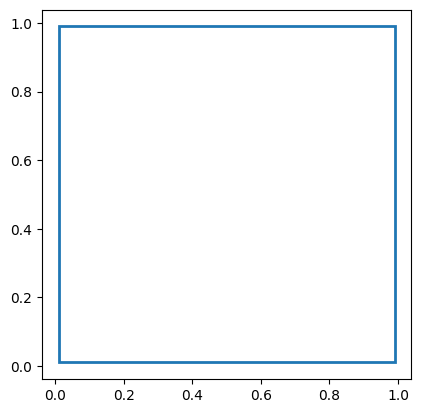

For this first partitioning step:
Number of boxes: 1
Active boxes mask: [ True]
---------------------------------------------------
After splitting iteration 1:


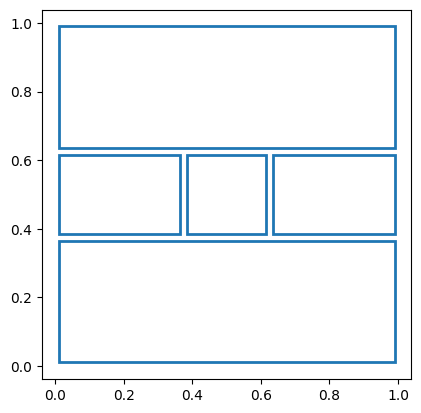

For this partitioning step 1:
Number of boxes: 5
Active boxes mask: [ True  True  True  True False]
---------------------------------------------------
After splitting iteration 2:


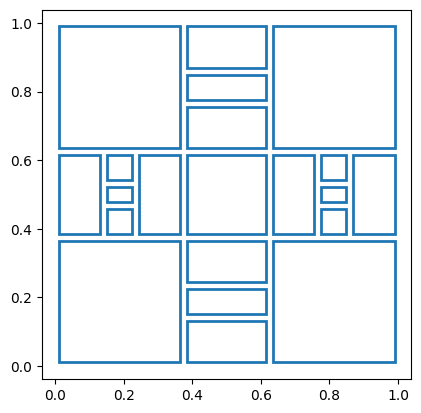

For this partitioning step 2:
Number of boxes: 21
Active boxes mask: [ True  True  True  True  True False  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True]
---------------------------------------------------
After splitting iteration 3:


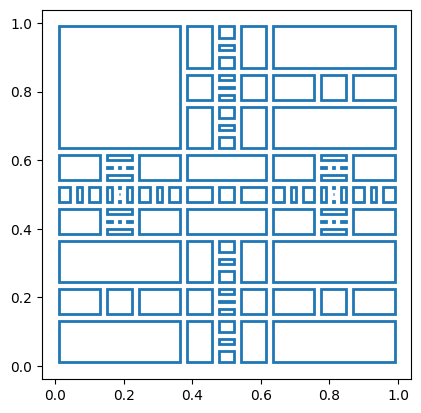

For this partitioning step 3:
Number of boxes: 101
Active boxes mask: [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True False  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True]
---------------------------------------------------
After splitting iteration 4:


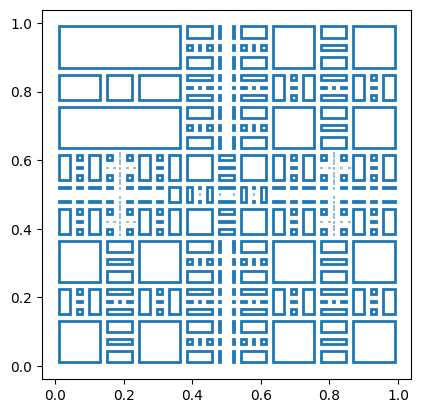

For this partitioning step 4:
Number of boxes: 501
Active boxes mask: [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True

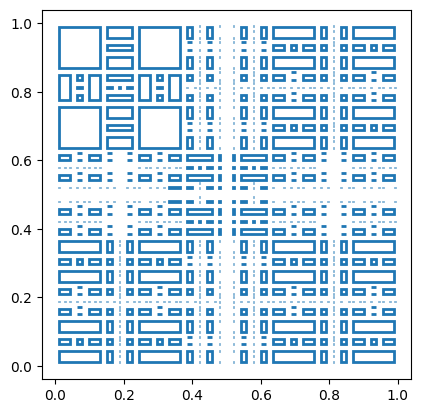

For this partitioning step 5:
Number of boxes: 2501
Active boxes mask: [ True  True  True ...  True  True  True]
---------------------------------------------------
After splitting iteration 6:


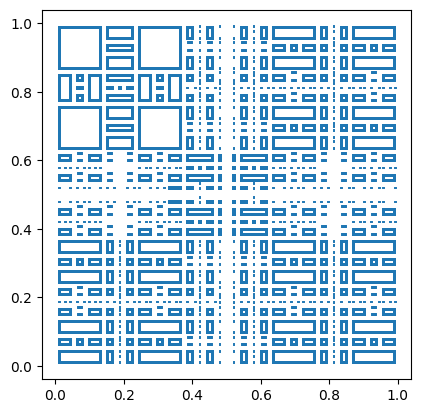

For this partitioning step 6:
Number of boxes: 12501
Active boxes mask: [ True  True  True ...  True  True  True]
---------------------------------------------------
After splitting iteration 7:


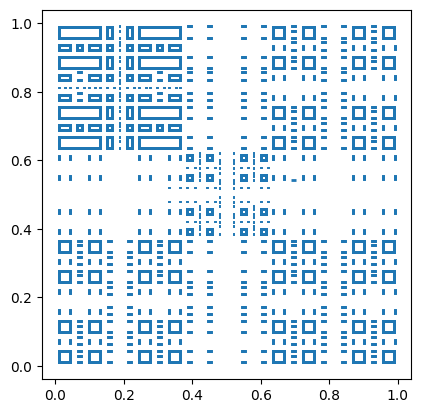

For this partitioning step 7:
Number of boxes: 62501
Active boxes mask: [ True  True  True ...  True  True  True]
---------------------------------------------------
After splitting iteration 8:


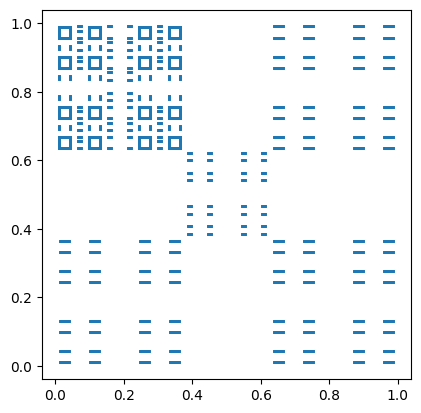

For this partitioning step 8:
Number of boxes: 312501
Active boxes mask: [ True  True  True ...  True  True  True]


In [11]:
bounds_L = cp.array([[0.0, 0.0]])
bounds_U = cp.array([[1.0, 1.0]])

w = bounds_U[0] - bounds_L[0]
d = bounds_L.shape[1]

print("Starting splitting test with intial box with bounds:", bounds_L, bounds_U)
print("Initial box width:", w)
print("Dimension:", d)
plot_rectangles(bounds_L, bounds_U)

n = bounds_L.shape[0]
active_boxes_mask = cp.array([True]*n)

print("For this first partitioning step:")
print("Number of boxes:", n)
print("Active boxes mask:", active_boxes_mask)

# Create a loop to do several splits
for split_iter in range(8):
    bounds_L, bounds_U = split_boxes(bounds_L, bounds_U, active_boxes_mask, w, n, d)

    print("---------------------------------------------------")
    print(f"After splitting iteration {split_iter+1}:")
    plot_rectangles(bounds_L, bounds_U)

    n = bounds_L.shape[0]
    active_boxes_mask = cp.array([True]*n)
    # Deactivate random boxes for testing
    cp.random.seed(split_iter)
    deactivate_indices = cp.random.choice(n, size=1, replace=False)
    active_boxes_mask[deactivate_indices] = False

    print(f"For this partitioning step {split_iter+1}:")
    print("Number of boxes:", n)
    print("Active boxes mask:", active_boxes_mask)

# 4 - Develop Split Script